<a href="https://colab.research.google.com/github/Shambhuraje1919/Machine_Learning_Paractice/blob/main/Heart_Disease_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uditjain13/heart-disease-risk-2026")

print("Path to dataset files:", path)

100%|██████████| 344k/344k [00:00<00:00, 15.1MB/s]

Extracting files...
Path to dataset files: /root/.cache/kagglehub/datasets/uditjain13/heart-disease-risk-2026/versions/3


In [2]:
import os
import pandas as pd
import numpy as np
import seaborn as sbn
import matplotlib.pyplot as plt
import plotly.express as px

In [3]:
os.listdir(path)

['heart_disease_risk_2026.csv']

In [4]:
df = pd.read_csv(os.path.join(path,'heart_disease_risk_2026.csv'))

In [5]:
df.head()

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
0,1,44,Male,117,74,193,57,106,119,112,...,False,Never,2.9,86,5.4,19.8,True,7731,62.9,0
1,2,57,Male,139,94,185,69,110,35,114,...,False,Never,3.0,132,4.3,45.8,True,2629,74.6,1
2,3,29,Male,128,78,197,52,108,157,95,...,False,Current,3.5,128,5.1,17.7,True,9290,65.7,0
3,4,72,Male,132,86,197,59,104,143,92,...,False,Never,2.7,18,6.8,63.6,True,7373,48.5,1
4,5,62,Female,116,75,154,65,75,104,135,...,True,Former,3.3,24,8.2,58.7,False,6331,47.3,1


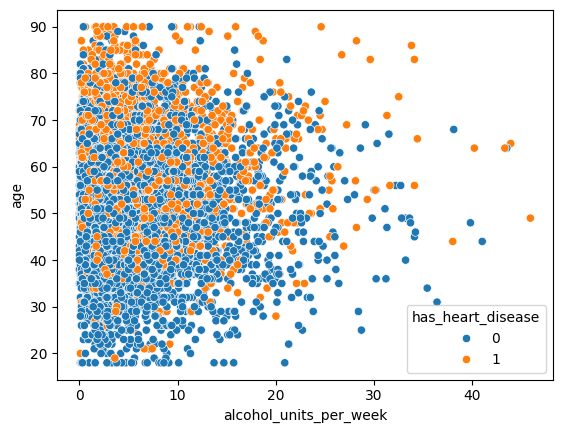

In [6]:
sbn.scatterplot(data = df , x= 'alcohol_units_per_week',y='age',color='red',hue='has_heart_disease')
plt.show()

In [7]:


fig = px.scatter_3d(
    df,
    x='alcohol_units_per_week',
    y='age',
    z='alcohol_units_per_week',

    color='has_heart_disease'
)
fig.show()

In [8]:
fig = px.scatter_3d(
    df,
    x='age',
    y='cholesterol_total',
    z='max_heart_rate_achieved',
    color='has_heart_disease',
    size='bmi',
    hover_data=['resting_bp_systolic', 'smoker_status'],
    color_continuous_scale='RdBu_r'
)

fig.update_layout(
    margin=dict(l=0, r=0, b=0, t=0),
    scene=dict(
        xaxis_title='Age',
        yaxis_title='Total Cholesterol',
        zaxis_title='Max Heart Rate Achieved'
    )
)

fig.show()

In [9]:
df.shape

(9000, 27)

In [10]:
df.tail()

,patient_id,age,sex,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,...,family_history,smoker_status,alcohol_units_per_week,exercise_minutes_per_week,sleep_hours,stress_score,wearable_owner,daily_steps,diet_quality_score,has_heart_disease
8995,8996,36,Female,108,63,178,68,82,158,96,...,False,Never,13.0,306,8.6,51.1,False,7144,58.1,0
8996,8997,44,Female,112,73,213,54,139,102,125,...,False,Former,3.4,76,6.5,37.1,False,7395,68.9,0
8997,8998,57,Female,144,93,198,66,113,79,102,...,False,Never,3.9,194,6.2,46.3,False,7424,70.2,0
8998,8999,61,Female,130,70,220,68,135,109,104,...,False,Former,3.9,139,5.0,66.5,False,5716,43.8,1
8999,9000,63,Female,152,104,215,64,117,109,120,...,False,Never,7.3,95,8.8,54.1,False,3860,54.5,0


In [11]:
df.columns.unique()

Index(['patient_id', 'age', 'sex', 'resting_bp_systolic',
       'resting_bp_diastolic', 'cholesterol_total', 'hdl', 'ldl',
       'triglycerides', 'fasting_blood_sugar', 'hba1c', 'bmi',
       'resting_heart_rate', 'max_heart_rate_achieved', 'chest_pain_type',
       'exercise_induced_angina', 'st_depression', 'family_history',
       'smoker_status', 'alcohol_units_per_week', 'exercise_minutes_per_week',
       'sleep_hours', 'stress_score', 'wearable_owner', 'daily_steps',
       'diet_quality_score', 'has_heart_disease'],
      dtype='object')

In [12]:
df['has_heart_disease']

,has_heart_disease
0,0
1,1
2,0
3,1
4,1
...,...
8995,0
8996,0
8997,0
8998,1


In [13]:
df.dtypes

,0
patient_id,int64
age,int64
sex,object
resting_bp_systolic,int64
resting_bp_diastolic,int64
cholesterol_total,int64
hdl,int64
ldl,int64
triglycerides,int64
fasting_blood_sugar,int64


In [14]:
df['sex']

,sex
0,Male
1,Male
2,Male
3,Male
4,Female
...,...
8995,Female
8996,Female
8997,Female
8998,Female


In [15]:
df = df.drop('patient_id',axis=1)

In [16]:
df['smoker_status']

,smoker_status
0,Never
1,Never
2,Current
3,Never
4,Former
...,...
8995,Never
8996,Former
8997,Never
8998,Former


In [17]:
df = pd.get_dummies(df, columns = ['smoker_status'],drop_first= True)

In [18]:
df.dtypes

,0
age,int64
sex,object
resting_bp_systolic,int64
resting_bp_diastolic,int64
cholesterol_total,int64
hdl,int64
ldl,int64
triglycerides,int64
fasting_blood_sugar,int64
hba1c,float64


In [19]:
df['chest_pain_type']

,chest_pain_type
0,Asymptomatic
1,Non-Anginal Pain
2,Asymptomatic
3,Asymptomatic
4,Atypical Angina
...,...
8995,Typical Angina
8996,Asymptomatic
8997,Asymptomatic
8998,Asymptomatic


In [20]:
df = pd.get_dummies(df,columns=['chest_pain_type'],drop_first=True)

In [21]:
df = pd.get_dummies(df, columns=['sex'],drop_first=True)

In [22]:
df.shape

(9000, 29)

In [23]:
x = df.drop('has_heart_disease',axis=1)

In [24]:
x.shape

(9000, 28)

In [25]:
y = df['has_heart_disease'].values

In [26]:
y.shape

(9000,)

In [27]:
y

array([0, 1, 0, ..., 0, 1, 0])

In [45]:
!pip install catboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00


In [47]:
 from sklearn.model_selection import train_test_split
 from sklearn.linear_model import LogisticRegression
 from xgboost import XGBClassifier
 from sklearn.ensemble import RandomForestClassifier
 from sklearn.metrics import accuracy_score, confusion_matrix
 from xgboost import XGBClassifier
 from lightgbm import LGBMClassifier
 from catboost import CatBoostClassifier

In [29]:
x_train , x_test , y_train , y_test = train_test_split(x,y,test_size=0.2, random_state=42)

In [30]:
x_train.head(2)

,age,resting_bp_systolic,resting_bp_diastolic,cholesterol_total,hdl,ldl,triglycerides,fasting_blood_sugar,hba1c,bmi,...,stress_score,wearable_owner,daily_steps,diet_quality_score,smoker_status_Former,smoker_status_Never,chest_pain_type_Atypical Angina,chest_pain_type_Non-Anginal Pain,chest_pain_type_Typical Angina,sex_Male
6317,61,133,91,167,53,103,78,103,4.8,22.3,...,50.0,True,6654,79.9,True,False,True,False,False,False
740,71,125,73,189,55,126,149,83,5.4,21.6,...,36.5,False,621,56.0,False,False,False,True,False,False


In [31]:
Logestic_model = LogisticRegression()

In [32]:
Random_forest_model= RandomForestClassifier(n_estimators = 10)

In [83]:
xgboost_model = XGBClassifier(
    verbose=2
)

In [79]:
lightboost = LGBMClassifier(
    n_estimators=100,
    num_leaves=31,
    learning_rate = 0.01,
    min_child_sample = 20,
    random_state = 42,
    verbose=2
)

In [71]:
catboost = CatBoostClassifier(
    iterations = 200,
    depth = 10,
    learning_rate = 0.05,
    verbose=2
)

In [80]:
lightboost.fit(x_train , y_train)

[LightGBM] [Warning] Unknown parameter: min_child_sample
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] Unknown parameter: min_child_sample
[LightGBM] [Info] Number of positive: 2171, number of negative: 5029
[LightGBM] [Debug] Dataset::GetMultiBinFromSparseFeatures: sparse rate 0.748472
[LightGBM] [Debug] Dataset::GetMultiBinFromAllFeatures: sparse rate 0.128733
[LightGBM] [Debug] init for col-wise cost 0.000424 seconds, init for row-wise cost 0.003086 seconds
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005645 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2865
[LightGBM] [Info] Number of data points in the train set: 7200, number of used features: 28
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.301528 -> initscore=-0.840033
[LightGBM] [Info] Start training from score -0.840033
[LightGBM] [Debug] Trained a tree with leaves = 31 and dep

LGBMClassifier(learning_rate=0.01, min_child_sample=20, random_state=42,
               verbose=2)

In [72]:
catboost.fit(x_train , y_train)

0:	learn: 0.6529025	total: 200ms	remaining: 39.8s
2:	learn: 0.5684110	total: 483ms	remaining: 31.7s
4:	learn: 0.5031832	total: 742ms	remaining: 28.9s
6:	learn: 0.4529435	total: 1.02s	remaining: 28.1s
8:	learn: 0.4163732	total: 1.26s	remaining: 26.9s
10:	learn: 0.3838462	total: 1.46s	remaining: 25s
12:	learn: 0.3576927	total: 1.76s	remaining: 25.3s
14:	learn: 0.3374412	total: 2.33s	remaining: 28.8s
16:	learn: 0.3209097	total: 2.66s	remaining: 28.6s
18:	learn: 0.3086844	total: 2.84s	remaining: 27.1s
20:	learn: 0.2958478	total: 2.99s	remaining: 25.5s
22:	learn: 0.2849644	total: 3.15s	remaining: 24.3s
24:	learn: 0.2759898	total: 3.32s	remaining: 23.3s
26:	learn: 0.2685972	total: 3.5s	remaining: 22.4s
28:	learn: 0.2618853	total: 3.67s	remaining: 21.7s
30:	learn: 0.2544457	total: 3.86s	remaining: 21s
32:	learn: 0.2480359	total: 4.04s	remaining: 20.4s
34:	learn: 0.2421512	total: 4.23s	remaining: 19.9s
36:	learn: 0.2357061	total: 4.43s	remaining: 19.5s
38:	learn: 0.2309794	total: 4.55s	remaini

CatBoostClassifier(depth=10, iterations=200, learning_rate=0.05, verbose=2)

In [84]:
Logestic_model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning:

lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression



LogisticRegression()

In [85]:
xgboost_model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning:

[05:56:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "verbose" } are not used.




XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=True, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

In [61]:
Random_forest_model.fit(x_train,y_train)

RandomForestClassifier(n_estimators=10)

In [62]:
pred_y1 = Random_forest_model.predict(x_test)

In [63]:
pred_y2 = Logestic_model.predict(x_test)

In [64]:
pred_y3 = xgboost_model.predict(x_test)

In [65]:
pred_y4 = lightboost.predict(x_test)

[LightGBM] [Warning] Unknown parameter: min_child_sample


In [75]:
pred_y5 = catboost.predict(x_test)

In [76]:
print('Random_Forest_prediction_accuracy', accuracy_score(y_test, pred_y1))
print('Random_Forest_prediction_accuracy', confusion_matrix(y_test, pred_y1))
print('- '*34)
print('XGBoost_prediction_accuracy', accuracy_score(y_test, pred_y2))
print('XGBoost_prediction_accuracy', confusion_matrix(y_test, pred_y2))
print('- '*34)
print('Logistic_prediction_accuracy', accuracy_score(y_test, pred_y3))
print('Logistic_prediction_accuracy', confusion_matrix(y_test, pred_y3))
print('- '*34)
print('XGBoost_prediction_accuracy', accuracy_score(y_test, pred_y4))
print('Logistic_prediction_accuracy', confusion_matrix(y_test, pred_y4))
print('- '*34)
print('Catboost_prediction_accuracy', accuracy_score(y_test, pred_y5))
print('Catboost_prediction_accuracy', confusion_matrix(y_test, pred_y5))

Random_Forest_prediction_accuracy 0.8605555555555555
Random_Forest_prediction_accuracy [[1166   78]
 [ 173  383]]
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
XGBoost_prediction_accuracy 0.8316666666666667
XGBoost_prediction_accuracy [[1142  102]
 [ 201  355]]
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Logistic_prediction_accuracy 0.8955555555555555
Logistic_prediction_accuracy [[1170   74]
 [ 114  442]]
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
XGBoost_prediction_accuracy 0.8761111111111111
Logistic_prediction_accuracy [[1198   46]
 [ 177  379]]
- - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - - 
Catboost_prediction_accuracy 0.8983333333333333
Catboost_prediction_accuracy [[1178   66]
 [ 117  439]]


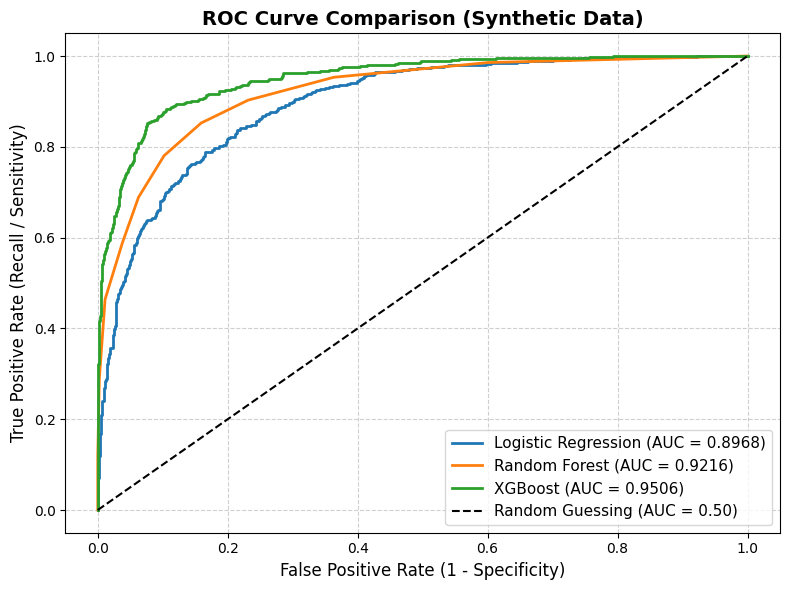

In [68]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

# 1. Get predicted probabilities for the positive class (column 1)
# Note: For XGBoost, if you are using the scikit-learn API (XGBClassifier), predict_proba works exactly the same way.
pred_prob_lr = Logestic_model.predict_proba(x_test)[:, 1]
pred_prob_rf = Random_forest_model.predict_proba(x_test)[:, 1]
pred_prob_xgb = xgboost_model.predict_proba(x_test)[:, 1]

# 2. Calculate ROC rates and AUC scores
fpr_lr, tpr_lr, _ = roc_curve(y_test, pred_prob_lr)
auc_lr = roc_auc_score(y_test, pred_prob_lr)

fpr_rf, tpr_rf, _ = roc_curve(y_test, pred_prob_rf)
auc_rf = roc_auc_score(y_test, pred_prob_rf)

fpr_xgb, tpr_xgb, _ = roc_curve(y_test, pred_prob_xgb)
auc_xgb = roc_auc_score(y_test, pred_prob_xgb)

# 3. Setup the plot canvas
plt.figure(figsize=(8, 6))

# 4. Plot individual curves with their calculated AUC scores in the legend
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC = {auc_lr:.4f})', linewidth=2)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.4f})', linewidth=2)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc_xgb:.4f})', linewidth=2)

# 5. Plot the baseline diagonal line (random guessing threshold)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guessing (AUC = 0.50)')

# 6. Customize chart labels and design aesthetics
plt.xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
plt.ylabel('True Positive Rate (Recall / Sensitivity)', fontsize=12)
plt.title('ROC Curve Comparison (Synthetic Data)', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# 7. Render layout tightly
plt.tight_layout()
plt.show()

In [42]:
import numpy as np

# Assuming you already computed fpr_xgb, tpr_xgb, and thresholds from roc_curve
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, pred_prob_xgb)

# Calculate Youden's J statistic: J = TPR - FPR
J = tpr_xgb - fpr_xgb
idx = np.argmax(J)
best_thresh = thresholds_xgb[idx]

print(f'Best Threshold for XGBoost: {best_thresh:.4f}')
print(f'Resulting True Positive Rate: {tpr_xgb[idx]:.4f}')
print(f'Resulting False Positive Rate: {fpr_xgb[idx]:.4f}')

Best Threshold for XGBoost: 0.2477
Resulting True Positive Rate: 0.8831
Resulting False Positive Rate: 0.1053


In [43]:
import seaborn as sbn